In [ ]:
#import packages
from __future__ import print_function
import tensorflow as tf
import keras
from tensorflow.keras import datasets, layers, models
import pandas as pd
import numpy as np
from keras.optimizers import Adam, SGD
# import warnings
# warnings.filterwarnings('ignore')
import cv2
from tensorflow.keras.utils import img_to_array, array_to_img, load_img, to_categorical
# from keras.preprocessing.image import ImageDataGenerator

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_lbl1 = pd.read_csv(r'/content/drive/MyDrive/pisc/d10.csv')

df_lbl1

,id_name,relation
0,1,2
1,2,1
2,3,2
3,4,2
4,5,2
...,...,...
9997,9998,3
9998,9999,1
9999,10000,2
10000,10001,3


In [ ]:
import zipfile
dn='/content/drive/MyDrive/pisc/d10.npy.zip'
zip_ref = zipfile.ZipFile(dn, "r")
zip_ref.extractall('/content/drive/MyDrive/pisc/')
zip_ref.close()

In [ ]:
data_x = []
data_x=np.load('/content/drive/MyDrive/pisc/d10.npy')

In [ ]:
data_y = []
for index, row in df_lbl1.iterrows():
  data_y.append(int(row['relation']))

In [ ]:
uniques, ids = np.unique(data_y, return_inverse=True)
labels1 = to_categorical(ids)
labels=ids
labels1

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       ...,
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.]], dtype=float32)

In [ ]:
from sklearn.model_selection import train_test_split

#Splitting
X_train, X_test, y_train, y_test = train_test_split(data_x, labels1, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)
print("Train: ", len(X_train), " Test; ",len(X_val), " Test: ",len(X_test))

Train:  8001  Test;  1000  Test:  1001


In [ ]:
print(X_train.shape)
print(y_train.shape)
input_shape = X_train[0].shape
print(input_shape)

(8001, 224, 224, 3)
(8001, 3)
(224, 224, 3)


In [ ]:
print(y_train.dtype)

float32


In [ ]:
y_train_l = np.argmax(y_train, axis=1)
ul = np.unique(y_train_l)
print(ul)

[0 1 2]


In [ ]:
y_val_l = np.argmax(y_val, axis=1)
ulv = np.unique(y_val_l)
print(ulv)

[0 1 2]


In [ ]:
y_test_l = np.argmax(y_test, axis=1)
ult = np.unique(y_test_l)
print(ult)

[0 1 2]


In [ ]:
# y1_train = y_train.astype(int)

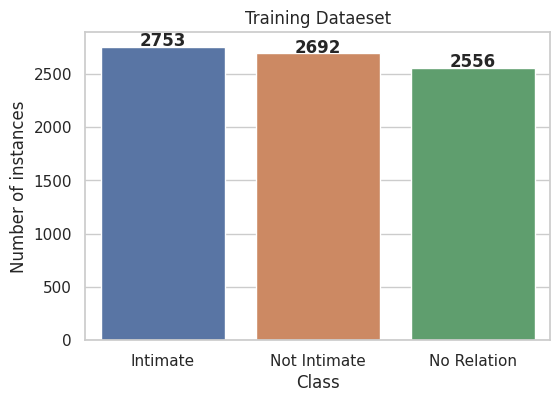

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# class_names = ['Friends', 'Family Members', 'Couple', 'Professional', 'Commercial', 'No Relation']
class_names = ['Intimate', 'Not Intimate', 'No Relation']
num_classes = len(class_names) #np.max(y_train_l) + 1
class_counts = np.zeros(num_classes, dtype=int)
for label in y_train_l:
    class_counts[label] += 1


sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
plt.title("Training Dataeset")
ax = sns.barplot(x=np.arange(num_classes), y=class_counts)
# ax.set_xticklabels(["Class {}".format(i+1) for i in range(num_classes)])
ax.set_xticklabels(class_names)
ax.set(xlabel="Class", ylabel="Number of instances")

for i, count in enumerate(class_counts):
    ax.text(i, count + 5, str(count), horizontalalignment='center', fontweight='bold')

plt.show()

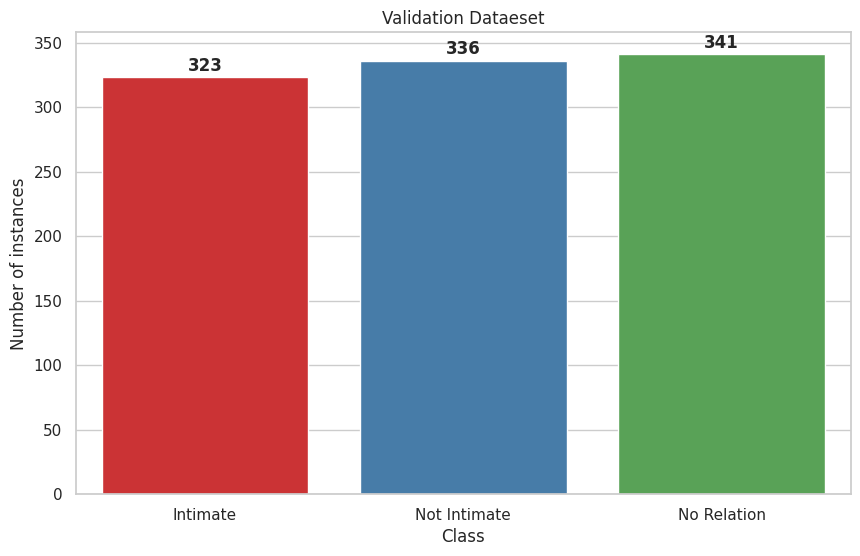

In [ ]:
# class_names = ['Friends', 'Family Members', 'Couple', 'Professional', 'Commercial', 'No Relation']
class_names = ['Intimate', 'Not Intimate', 'No Relation']
num_classes = len(class_names) #np.max(y_train_l) + 1
class_counts = np.zeros(num_classes, dtype=int)
for label in y_val_l:
    class_counts[label] += 1



sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
plt.title("Validation Dataeset")
ax = sns.barplot(x=np.arange(num_classes), y=class_counts, palette= "Set1")
# ax.set_xticklabels(["Class {}".format(i+1) for i in range(num_classes)])
ax.set_xticklabels(class_names)
ax.set(xlabel="Class", ylabel="Number of instances")


for i, count in enumerate(class_counts):
    ax.text(i, count + 5, str(count), horizontalalignment='center', fontweight='bold')

plt.show()

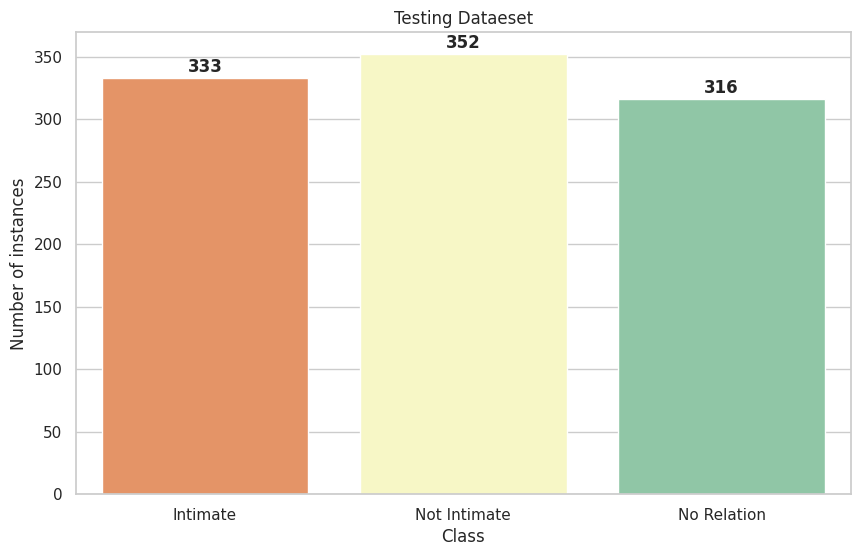

In [ ]:
# class_names = ['Friends', 'Family Members', 'Couple', 'Professional', 'Commercial', 'No Relation']
class_names = ['Intimate', 'Not Intimate', 'No Relation']
num_classes = len(class_names) #np.max(y_train_l) + 1
class_counts = np.zeros(num_classes, dtype=int)
for label in y_test_l:
    class_counts[label] += 1


sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
plt.title("Testing Dataeset")
ax = sns.barplot(x=np.arange(num_classes), y=class_counts, palette= "Spectral")
# ax.set_xticklabels(["Class {}".format(i+1) for i in range(num_classes)])
ax.set_xticklabels(class_names)
ax.set(xlabel="Class", ylabel="Number of instances")

for i, count in enumerate(class_counts):
    ax.text(i, count + 5, str(count), horizontalalignment='center', fontweight='bold')

plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the hyperparameters
num_classes = 3
image_size = 224
batch_size = 32
epochs = 50
learning_rate = 0.0001

# y_train = y_train.astype('int32')
# y_val = y_val.astype('int32')

y_train = y_train.astype('float32')
y_val = y_val.astype('float32')

# Create an ImageDataGenerator for data augmentation
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest")

# Create an ImageDataGenerator for the validation data
val_datagen = ImageDataGenerator(
        rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)
# Load the training data with data augmentation
train_data = train_datagen.flow(
    x=X_train,
    y=y_train,
    batch_size=batch_size,
    shuffle=True)

# Load the validation data
val_data = val_datagen.flow(
    x=X_val,
    y=y_val,
    batch_size=batch_size,
    shuffle=False)

# # Compute class weights to handle imbalanced classes
# class_weights = dict(zip(range(num_classes), tf.math.divide_no_nan(train_data.n, num_classes * tf.reduce_sum(train_data.classes, axis=0))))

# Create a training dataset
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(buffer_size=len(X_train)).batch(batch_size)

# Create a validation dataset
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(batch_size)

# Compute class weights to handle imbalanced classes
class_weights = dict(zip(range(num_classes), tf.math.divide_no_nan(tf.cast(train_data.n, tf.float32), num_classes * tf.reduce_sum(train_data.y, axis=0))))
# Compute class weights to handle imbalanced classes
# class_weights = dict(zip(range(num_classes), tf.math.divide_no_nan(train_data.n, num_classes * tf.reduce_sum(train_data.y, axis=0))))


In [ ]:
class_weights

{0: <tf.Tensor: shape=(), dtype=float32, numpy=0.9687613>,
 1: <tf.Tensor: shape=(), dtype=float32, numpy=0.99071324>,
 2: <tf.Tensor: shape=(), dtype=float32, numpy=1.0434272>}

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# Basic Feature Extraction using ResNet50
base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Transformer Block for simplicity
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential(
            [layers.Dense(ff_dim, activation="relu"), layers.Dense(embed_dim),]
        )
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# Construct the Model
class MT_SRR(Model):
    def __init__(self, num_classes=6):
        super(MT_SRR, self).__init__()
        self.resnet = base_model
        self.transformer = TransformerBlock(embed_dim=2048, num_heads=8, ff_dim=512)
        self.global_avg_pool = layers.GlobalAveragePooling2D()
        self.fc = layers.Dense(3, activation='softmax')

    def call(self, inputs):
        x = self.resnet(inputs)
        x = self.transformer(x)
        x = self.global_avg_pool(x)
        return self.fc(x)

model = MT_SRR()


In [ ]:
def adaptive_margin_loss(nummax, ny, y_true, y_pred):
    # Calculate cosine similarity
    y_true_normalized = tf.nn.l2_normalize(y_true, axis=-1)
    y_pred_normalized = tf.nn.l2_normalize(y_pred, axis=-1)
    cosine_similarity = tf.reduce_sum(tf.multiply(y_true_normalized, y_pred_normalized), axis=-1)

    # Calculate the adaptive margin
    delta = (nummax / ny) * cosine_similarity

    # Standard cross entropy
    ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)

    # Add the margin
    loss = tf.math.log(1 + tf.math.exp(ce + delta))

    return loss


In [ ]:
lr = 1e-4
optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
nummax = 1000
ny = 500

model.compile(optimizer=optimizer,
              loss=lambda y_true, y_pred: adaptive_margin_loss(nummax, ny, y_true, y_pred),
              metrics=['accuracy'])

In [ ]:
epochs = 20
batch_size = 32

history = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    class_weight=class_weights,
                    validation_data=(X_val, y_val))

Epoch 1/20
251/251 [==============================] - 67s 102ms/step - loss: 2.4028 - accuracy: 0.5156 - val_loss: 2.3519 - val_accuracy: 0.3410
Epoch 2/20
251/251 [==============================] - 23s 90ms/step - loss: 2.3334 - accuracy: 0.6198 - val_loss: 2.8468 - val_accuracy: 0.3420
Epoch 3/20
251/251 [==============================] - 23s 90ms/step - loss: 2.3128 - accuracy: 0.6818 - val_loss: 4.1337 - val_accuracy: 0.3450
Epoch 4/20
251/251 [==============================] - 22s 90ms/step - loss: 2.3079 - accuracy: 0.6755 - val_loss: 2.3454 - val_accuracy: 0.6200
Epoch 5/20
251/251 [==============================] - 22s 89ms/step - loss: 2.2794 - accuracy: 0.7379 - val_loss: 2.4113 - val_accuracy: 0.6520
Epoch 6/20
251/251 [==============================] - 22s 89ms/step - loss: 2.2733 - accuracy: 0.7674 - val_loss: 2.3772 - val_accuracy: 0.7130
Epoch 7/20
251/251 [==============================] - 22s 89ms/step - loss: 2.2636 - accuracy: 0.7838 - val_loss: 2.3745 - val_accuracy

In [ ]:
from sklearn.metrics import average_precision_score

# Use the model to make predictions on the test dataset
predicted_probs = model.predict(X_test)

# Calculate the average precision for each class
average_precision = average_precision_score(y_test, predicted_probs, average=None)

# Calculate the mean average precision
mean_average_precision = average_precision_score(y_test, predicted_probs, average='macro')

32/32 [==============================] - 2s 34ms/step


In [ ]:
print(mean_average_precision)

0.8883224493199023


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print('Test loss:', loss)
print('Test accuracy:', accuracy)

32/32 [==============================] - 1s 27ms/step - loss: 2.4290 - accuracy: 0.7992
Test loss: 2.4290127754211426
Test accuracy: 0.7992007732391357


In [ ]:
# y_pred = model.predict(X_test)
y_pred = predicted_probs
y_pred_labels = uniques[np.argmax(y_pred, axis=1)]
print(y_pred_labels)
y_test_labels = uniques[np.argmax(y_test, axis=1)]
print(y_pred_labels)
accuracy = np.mean(y_pred_labels == y_test_labels)
print('Test accuracy:', accuracy)

[1 3 2 ... 3 3 1]
[1 3 2 ... 3 3 1]
Test accuracy: 0.7992007992007992


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_labels, y_pred_labels)

print('Confusion matrix:')
print(cm)

Confusion matrix:
[[291  25  17]
 [ 75 263  14]
 [ 52  18 246]]


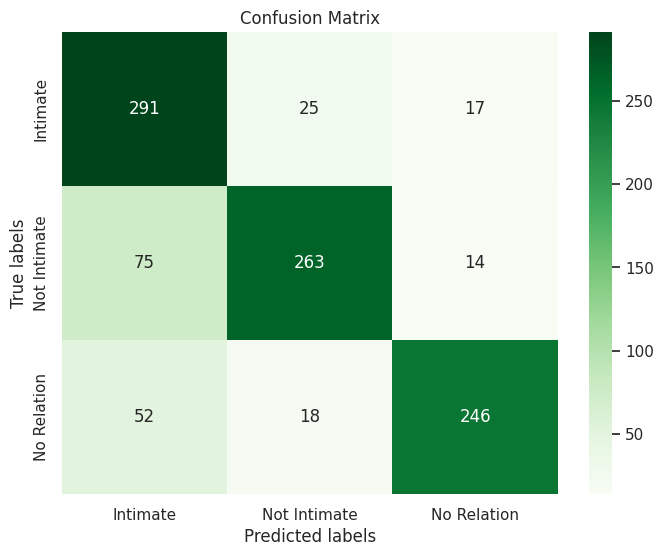

In [ ]:
# class_names = ['Friends', 'Family Members', 'Couple', 'Professional', 'Commercial', 'No Relation']
class_names = ['Intimate', 'Not Intimate', 'No Relation']

cm = confusion_matrix(y_test_labels, y_pred_labels)

cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_df, fmt='d', annot=True, cmap='Greens', ax=ax)

plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')

plt.show()

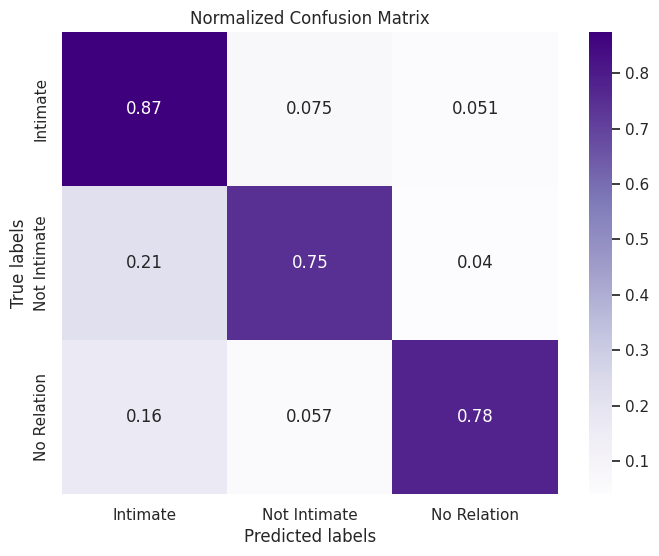

In [ ]:
# class_names = ['Friends', 'Family Members', 'Couple', 'Professional', 'Commercial', 'No Relation']
class_names = ['Intimate', 'Not Intimate', 'No Relation']
cm = confusion_matrix(y_test_labels, y_pred_labels)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

cm_norm_df = pd.DataFrame(cm_norm, index=class_names, columns=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_norm_df, annot=True, cmap='Purples', ax=ax)

plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Normalized Confusion Matrix')

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test_labels, y_pred_labels, target_names=class_names))

              precision    recall  f1-score   support

    Intimate       0.70      0.87      0.77       333
Not Intimate       0.86      0.75      0.80       352
 No Relation       0.89      0.78      0.83       316

    accuracy                           0.80      1001
   macro avg       0.81      0.80      0.80      1001
weighted avg       0.81      0.80      0.80      1001



In [ ]:
report = classification_report(y_test_labels, y_pred_labels, target_names=class_names, output_dict=True)

print("Weighted Average Precision: {:.2f}".format(report['weighted avg']['precision']))
print("Weighted Average Recall: {:.2f}".format(report['weighted avg']['recall']))
print("Weighted Average F1-score: {:.2f}".format(report['weighted avg']['f1-score']))
print("Weighted Average Support: {:.2f}".format(report['weighted avg']['support']))

Weighted Average Precision: 0.80
Weighted Average Recall: 0.80
Weighted Average F1-score: 0.80
Weighted Average Support: 703.00


In [ ]:
model.save('/content/drive/MyDrive/pisc/mlt2f', save_format='tf')